In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('adultt.csv')

for c in df.select_dtypes(exclude='number').columns:
    df[c] = df[c].str.strip()
df = df.replace('?', pd.NA).drop_duplicates().reset_index(drop=True)

df.to_csv('adult_cleaned.csv', index=False)
print(df.shape)
df.head()

(32537, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,<NA>,77053,HS-grad,9,Widowed,<NA>,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,<NA>,186061,Some-college,10,Widowed,<NA>,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


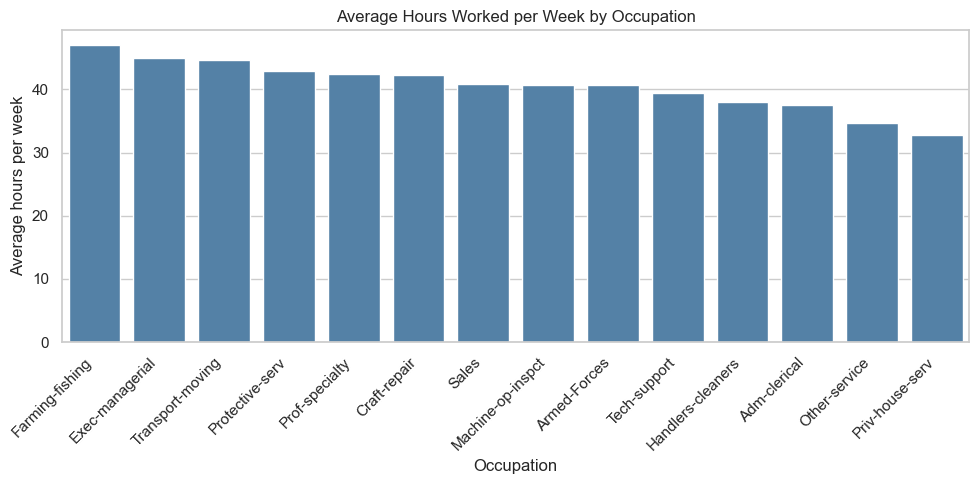

occupation
Farming-fishing      46.99
Exec-managerial      44.99
Transport-moving     44.66
Protective-serv      42.87
Prof-specialty       42.39
Craft-repair         42.31
Sales                40.78
Machine-op-inspct    40.75
Armed-Forces         40.67
Tech-support         39.46
Handlers-cleaners    37.93
Adm-clerical         37.57
Other-service        34.70
Priv-house-serv      32.79
Name: hours.per.week, dtype: float64


In [2]:
avg_hours = (df.dropna(subset=['occupation'])
               .groupby('occupation')['hours.per.week']
               .mean()
               .sort_values(ascending=False))

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_hours.index, y=avg_hours.values, color='steelblue')
plt.title('Average Hours Worked per Week by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Average hours per week')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(avg_hours.round(2))

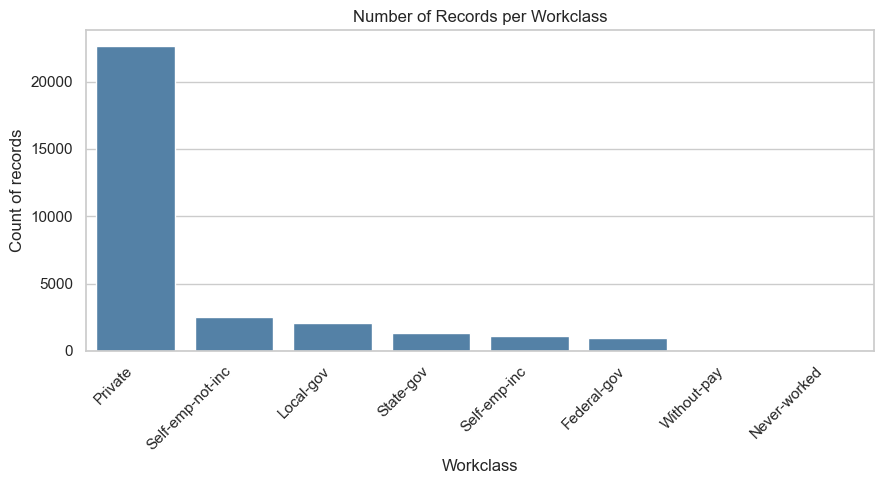

workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(9, 5))
order = df['workclass'].value_counts().index
sns.countplot(data=df, x='workclass', order=order, color='steelblue')
plt.title('Number of Records per Workclass')
plt.xlabel('Workclass')
plt.ylabel('Count of records')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(df['workclass'].value_counts())

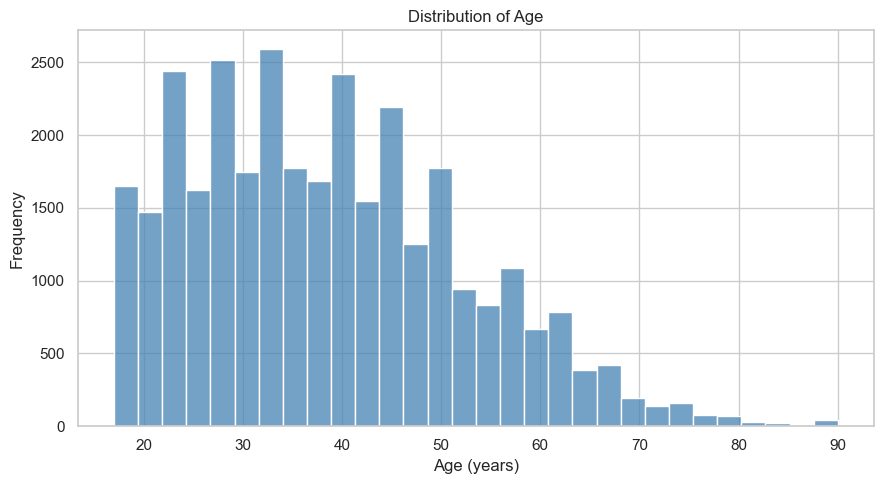

Skewness: 0.558


In [4]:
plt.figure(figsize=(9, 5))
sns.histplot(df['age'], bins=30, color='steelblue')
plt.title('Distribution of Age')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Skewness:', round(df['age'].skew(), 3))

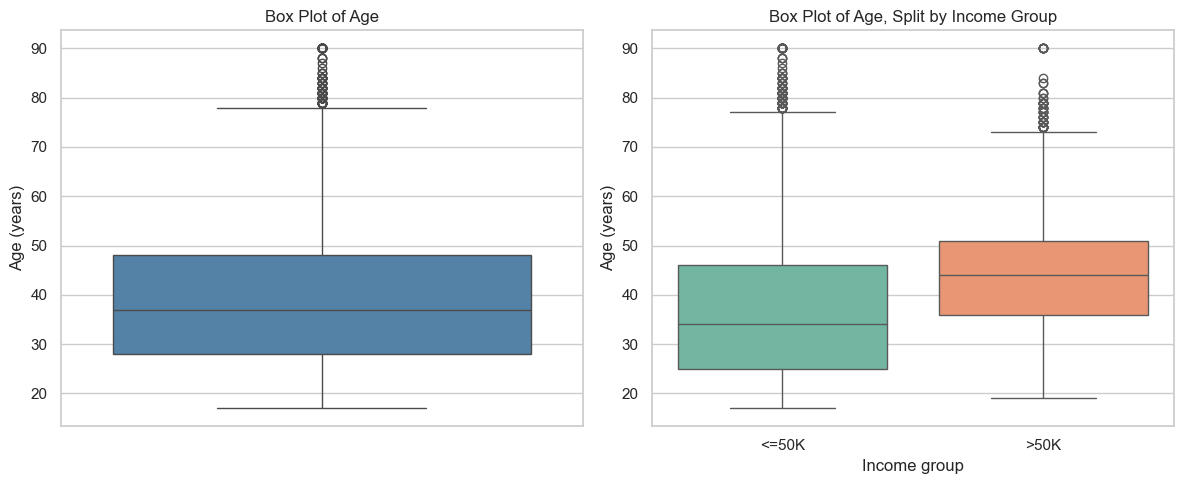

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['age'], color='steelblue', ax=axes[0])
axes[0].set_title('Box Plot of Age')
axes[0].set_ylabel('Age (years)')

sns.boxplot(data=df, x='income', y='age', hue='income',
            palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Box Plot of Age, Split by Income Group')
axes[1].set_xlabel('Income group')
axes[1].set_ylabel('Age (years)')

plt.tight_layout()
plt.show()

In [6]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['age'] < lower) | (df['age'] > upper)]

print('Q1 =', Q1, '| Q3 =', Q3, '| IQR =', IQR)
print('Lower bound =', lower, '| Upper bound =', upper)
print('Number of IQR outliers:', len(outliers))
print('Ages flagged:', outliers['age'].min(), 'to', outliers['age'].max())

Q1 = 28.0 | Q3 = 48.0 | IQR = 20.0
Lower bound = -2.0 | Upper bound = 78.0
Number of IQR outliers: 142
Ages flagged: 79 to 90


### IQR Outlier Detection

The IQR method identified **142 outliers**, with ages ranging from **79–90**. This differs from the approximately **11 points** counted visually in the box plot because multiple people with the same whole-number age overlap at the same position. Therefore, the box plot shows only **11 distinct dot positions**, while the IQR method counts all **142 rows**. Both methods identify the same outlier region: ages **above 78**.


In [7]:
from scipy import stats

df['zscore'] = stats.zscore(df['age'])
outliers_z = df[df['zscore'].abs() > 3]

print('Number of z-score outliers:', len(outliers_z))
print('Ages flagged:', outliers_z['age'].min(), 'to', outliers_z['age'].max())
print('Mean =', round(df['age'].mean(), 2),
      '| Std =', round(df['age'].std(ddof=0), 2),
      '| Upper cutoff = mean + 3*std =', round(df['age'].mean() + 3 * df['age'].std(ddof=0), 2))

Number of z-score outliers: 120
Ages flagged: 80 to 90
Mean = 38.59 | Std = 13.64 | Upper cutoff = mean + 3*std = 79.5


No — IQR flags 142 outliers while the z-score method flags 120 (ages 80–90 only). The difference comes from the distribution's shape: age is right-skewed, not symmetric, as seen in the histogram and box plot.

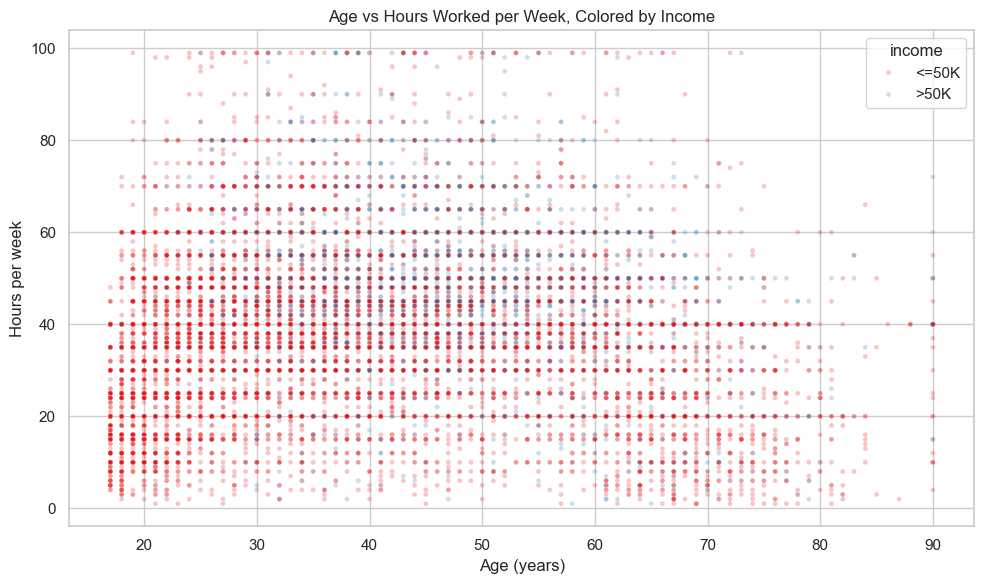

Correlation: 0.069


In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='hours.per.week', hue='income',
                alpha=0.25, s=12, palette='Set1')
plt.title('Age vs Hours Worked per Week, Colored by Income')
plt.xlabel('Age (years)')
plt.ylabel('Hours per week')
plt.tight_layout()
plt.show()

print('Correlation:', round(df['age'].corr(df['hours.per.week']), 3))

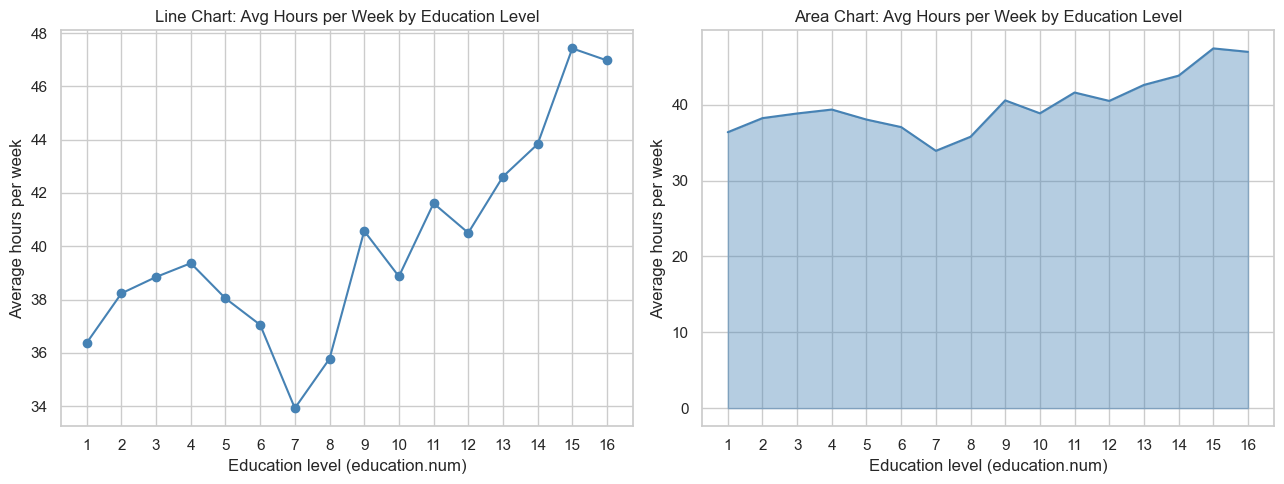

education.num
1     36.4
2     38.2
3     38.8
4     39.4
5     38.0
6     37.1
7     33.9
8     35.8
9     40.6
10    38.9
11    41.6
12    40.5
13    42.6
14    43.8
15    47.4
16    47.0
Name: hours.per.week, dtype: float64


In [9]:
edu_hours = df.groupby('education.num')['hours.per.week'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(edu_hours.index, edu_hours.values, marker='o', color='steelblue')
axes[0].set_title('Line Chart: Avg Hours per Week by Education Level')

axes[1].fill_between(edu_hours.index, edu_hours.values, color='steelblue', alpha=0.4)
axes[1].plot(edu_hours.index, edu_hours.values, color='steelblue')
axes[1].set_title('Area Chart: Avg Hours per Week by Education Level')

for ax in axes:
    ax.set_xlabel('Education level (education.num)')
    ax.set_ylabel('Average hours per week')
    ax.set_xticks(range(1, 17))

plt.tight_layout()
plt.show()

print(edu_hours.round(1))

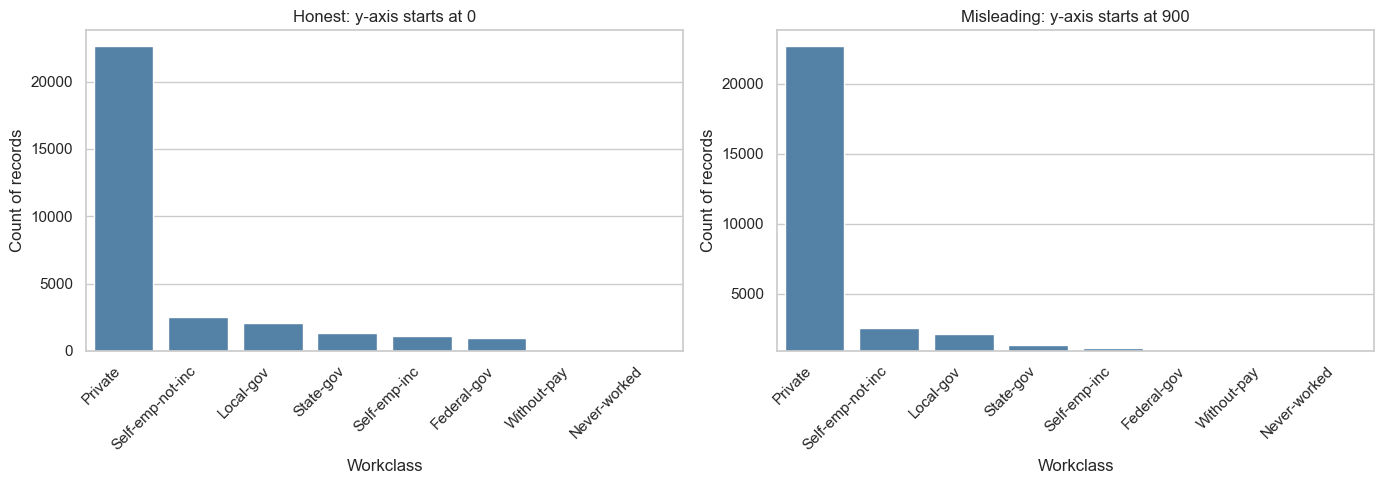

In [10]:
order = df['workclass'].value_counts().index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='workclass', order=order, color='steelblue', ax=axes[0])
axes[0].set_title('Honest: y-axis starts at 0')

sns.countplot(data=df, x='workclass', order=order, color='steelblue', ax=axes[1])
axes[1].set_ylim(bottom=900)
axes[1].set_title('Misleading: y-axis starts at 900')

for ax in axes:
    ax.set_xlabel('Workclass')
    ax.set_ylabel('Count of records')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()